#### Cell 1 — Import Library

In [55]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.pyfunc
import pickle
import os
import warnings
import random
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.forecasting.theta import ThetaModel
from sklearn.linear_model import OrthogonalMatchingPursuit
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

##### Cell 2 — Load & Siapkan Data

In [56]:
import pandas as pd
from sqlalchemy import create_engine

DB_USER="postgres.utwachpawsvnmpavjexg"
DB_PASSWORD="PredixViz02" 
DB_HOST="aws-1-ap-southeast-1.pooler.supabase.com"          
DB_PORT=6543
DB_NAME="postgres"



engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Test koneksi
try:
    with engine.connect() as conn:
        print("✅ Koneksi berhasil!")
except Exception as e:
    print(f"❌ Gagal konek: {e}")

# Tabel utama untuk modeling
df_orders   = pd.read_sql("SELECT * FROM orders", engine)
df_products = pd.read_sql("SELECT * FROM products", engine)
df_customers = pd.read_sql("SELECT * FROM customers", engine)
df_locations = pd.read_sql("SELECT * FROM locations", engine)
df_ts_sales_monthly = pd.read_sql("SELECT * FROM ts_sales_monthly", engine)

print("Orders:", df_orders.shape)
print("Products:", df_products.shape)
df_orders.head()

# %%
df_monthly = pd.read_sql("SELECT * FROM ts_sales_monthly", engine)
print(df_monthly.shape)
df_monthly.head()
df_ts_sales_monthly.head()

df_monthly = pd.read_sql("SELECT * FROM ts_sales_monthly", engine)

# Agregasi per Category per YearMonth (jumlahkan semua sub_category)
df_monthly['YearMonth'] = pd.to_datetime(df_monthly[['year', 'month']].assign(day=1))
df = df_monthly.groupby(['YearMonth', 'category'])['total_sales'].sum().reset_index()
df.columns = ['YearMonth', 'Category', 'Total_Sales']
df = df.sort_values('YearMonth').reset_index(drop=True)

df_furniture  = df[df['Category'] == 'Furniture'][['YearMonth', 'Total_Sales']].reset_index(drop=True)
df_office     = df[df['Category'] == 'Office Supplies'][['YearMonth', 'Total_Sales']].reset_index(drop=True)
df_technology = df[df['Category'] == 'Technology'][['YearMonth', 'Total_Sales']].reset_index(drop=True)

print("Furniture:", df_furniture.shape)
print("Office Supplies:", df_office.shape)
print("Technology:", df_technology.shape)

✅ Koneksi berhasil!
Orders: (9994, 10)
Products: (1850, 4)
(782, 11)
Furniture: (48, 2)
Office Supplies: (48, 2)
Technology: (48, 2)


#### Cell 3 — Fungsi Hitung Metrics

In [57]:
def compute_metrics(actual, predicted, train_series):
    actual       = np.array(actual, dtype=float)
    predicted    = np.array(predicted, dtype=float)
    train_series = np.array(train_series, dtype=float)
    mae          = np.mean(np.abs(actual - predicted))
    rmse         = np.sqrt(np.mean((actual - predicted) ** 2))
    mape         = np.mean(np.abs((actual - predicted) / actual)) * 100
    ss_res       = np.sum((actual - predicted) ** 2)
    ss_tot       = np.sum((actual - np.mean(actual)) ** 2)
    r2           = 1 - (ss_res / ss_tot)
    naive_err    = np.mean(np.abs(np.diff(train_series)))  # pakai train, bukan actual
    rmsse        = rmse / (naive_err * np.sqrt(len(actual)))
    return {"MAE": round(mae, 4), "RMSE": round(rmse, 4),
            "MAPE": round(mape, 4), "R2": round(r2, 4),
            "RMSSE": round(rmsse, 4)}


#### Cell 4 — Fungsi Split Train-Test

In [58]:
def split_data_3way(df, train_ratio=0.7, val_ratio=0.15):
    n          = len(df)
    train_end  = int(n * train_ratio)
    val_end    = int(n * (train_ratio + val_ratio))
    
    train = df.iloc[:train_end]['Total_Sales'].values
    val   = df.iloc[train_end:val_end]['Total_Sales'].values
    test  = df.iloc[val_end:]['Total_Sales'].values
    
    return train, val, test

train_fur,  val_fur,  test_fur  = split_data_3way(df_furniture)
train_off,  val_off,  test_off  = split_data_3way(df_office)
train_tech, val_tech, test_tech = split_data_3way(df_technology)

print("=== SPLIT DATA ===")
print(f"Furniture       - Train: {len(train_fur)}, Val: {len(val_fur)}, Test: {len(test_fur)}")
print(f"Office Supplies - Train: {len(train_off)}, Val: {len(val_off)}, Test: {len(test_off)}")
print(f"Technology      - Train: {len(train_tech)}, Val: {len(val_tech)}, Test: {len(test_tech)}")

# Verifikasi tidak overlap
print("\n=== VERIFIKASI TIDAK OVERLAP ===")
for cat, df_cat in [("Furniture", df_furniture), ("Office Supplies", df_office), ("Technology", df_technology)]:
    n         = len(df_cat)
    train_end = int(n * 0.7)
    val_end   = int(n * 0.85)
    print(f"\n{cat}:")
    print(f"  Train akhir : {df_cat.iloc[train_end-1]['YearMonth'].strftime('%Y-%m')}")
    print(f"  Val awal    : {df_cat.iloc[train_end]['YearMonth'].strftime('%Y-%m')}")
    print(f"  Val akhir   : {df_cat.iloc[val_end-1]['YearMonth'].strftime('%Y-%m')}")
    print(f"  Test awal   : {df_cat.iloc[val_end]['YearMonth'].strftime('%Y-%m')}")
    print(f"  Test akhir  : {df_cat.iloc[-1]['YearMonth'].strftime('%Y-%m')}")


=== SPLIT DATA ===
Furniture       - Train: 33, Val: 7, Test: 8
Office Supplies - Train: 33, Val: 7, Test: 8
Technology      - Train: 33, Val: 7, Test: 8

=== VERIFIKASI TIDAK OVERLAP ===

Furniture:
  Train akhir : 2016-09
  Val awal    : 2016-10
  Val akhir   : 2017-04
  Test awal   : 2017-05
  Test akhir  : 2017-12

Office Supplies:
  Train akhir : 2016-09
  Val awal    : 2016-10
  Val akhir   : 2017-04
  Test awal   : 2017-05
  Test akhir  : 2017-12

Technology:
  Train akhir : 2016-09
  Val awal    : 2016-10
  Val akhir   : 2017-04
  Test awal   : 2017-05
  Test akhir  : 2017-12


#### Cell 5 — Fungsi OMP (dengan Deseasonalize + Detrend)

In [59]:
def deseasonalize(series, period=12):
    seasonal_means = np.array([
        np.mean(series[i::period]) for i in range(period)
    ])
    seasonal_component = np.array([
        seasonal_means[i % period] for i in range(len(series))
    ])
    return series / seasonal_component, seasonal_component

def detrend(series):
    x     = np.arange(len(series))
    coefs = np.polyfit(x, series, 1)
    trend = np.polyval(coefs, x)
    return series - trend, coefs

def create_lag_features(series, n_lags=12):
    X, y = [], []
    for i in range(n_lags, len(series)):
        X.append(series[i - n_lags:i])
        y.append(series[i])
    return np.array(X), np.array(y)

def train_omp(train, period=12, n_lags=12, n_nonzero_coefs=5):
    # Deseasonalize
    deseas_train, seas_comp = deseasonalize(train, period)
    # Detrend
    detrend_train, trend_coefs = detrend(deseas_train)
    # Lag features
    X_train, y_train = create_lag_features(detrend_train, n_lags)
    # Scaler
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    # OMP
    omp = OrthogonalMatchingPursuit(n_nonzero_coefs=n_nonzero_coefs)
    omp.fit(X_train, y_train)
    return omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train

def predict_omp(omp, scaler, train, seas_comp, trend_coefs, detrend_train, steps, period=12, n_lags=12):
    history  = list(detrend_train)
    preds    = []
    for i in range(steps):
        x    = np.array(history[-n_lags:]).reshape(1, -1)
        x    = scaler.transform(x)
        pred = omp.predict(x)[0]
        preds.append(pred)
        history.append(pred)
    # Re-add trend
    n_train      = len(train)
    trend_future = np.polyval(trend_coefs, np.arange(n_train, n_train + steps))
    preds        = np.array(preds) + trend_future
    # Re-add seasonality
    seas_future  = np.array([seas_comp[i % period] for i in range(n_train, n_train + steps)])
    preds        = preds * seas_future
    return preds

#### Cell 6 — Set MLflow

In [60]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Superstore_TimeSeries")

<Experiment: artifact_location='file:c:/Users/hafizh/OneDrive/Dokumen/Kuliah/Semester 4/PBL MODEL FIX/mlruns/1', creation_time=1780887234886, experiment_id='1', last_update_time=1780887234886, lifecycle_stage='active', name='Superstore_TimeSeries', tags={}, trace_location=None, workspace='default'>

#### Cell 7 — Training 9 Model (Baseline)

In [61]:
results    = {}
categories = {
    "Furniture":       (train_fur,  val_fur,  test_fur),
    "Office Supplies": (train_off,  val_off,  test_off),
    "Technology":      (train_tech, val_tech, test_tech)
}

for cat, (train, val, test) in categories.items():
    results[cat] = {}
    cat_slug     = cat.replace(" ", "_")

    # ── ARIMA ──────────────────────────────────────────
    with mlflow.start_run(run_name=f"ARIMA_{cat_slug}"):
        try:
            model  = ARIMA(train, order=(1,1,1), seasonal_order=(1,1,0,12))
            fitted = model.fit()
            pred   = fitted.forecast(steps=len(val))  # ← pakai val
            m      = compute_metrics(val, pred, train)
            results[cat]['ARIMA'] = {'metrics': m, 'model': fitted, 'type': 'arima'}
            mlflow.log_param("model", "ARIMA")
            mlflow.log_param("category", cat)
            mlflow.log_param("order", "(1,1,1)")
            mlflow.log_param("seasonal_order", "(1,1,0,12)")
            mlflow.log_param("split", "train-val-test")
            mlflow.log_metrics(m)
            print(f"ARIMA {cat}: {m}")
        except Exception as e:
            print(f"ARIMA {cat} error: {e}")

    # ── THETA ──────────────────────────────────────────
    with mlflow.start_run(run_name=f"Theta_{cat_slug}"):
        try:
            model  = ThetaModel(train, period=12)
            fitted = model.fit()
            pred   = fitted.forecast(steps=len(val))  # ← pakai val
            m      = compute_metrics(val, pred, train)
            results[cat]['Theta'] = {'metrics': m, 'model': fitted, 'type': 'theta'}
            mlflow.log_param("model", "Theta")
            mlflow.log_param("category", cat)
            mlflow.log_param("period", 12)
            mlflow.log_param("split", "train-val-test")
            mlflow.log_metrics(m)
            print(f"Theta {cat}: {m}")
        except Exception as e:
            print(f"Theta {cat} error: {e}")

    # ── OMP ────────────────────────────────────────────
    with mlflow.start_run(run_name=f"OMP_{cat_slug}"):
        try:
            omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train = train_omp(train)
            pred = predict_omp(omp, scaler, train, seas_comp, trend_coefs,
                               detrend_train, steps=len(val), period=12)  # ← pakai val
            m    = compute_metrics(val, pred, train)
            results[cat]['OMP'] = {
                'metrics': m,
                'model':   (omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train),
                'type':    'omp'
            }
            mlflow.log_param("model", "OMP")
            mlflow.log_param("category", cat)
            mlflow.log_param("n_nonzero_coefs", 5)
            mlflow.log_param("n_lags", 12)
            mlflow.log_param("split", "train-val-test")
            mlflow.log_metrics(m)
            print(f"OMP {cat}: {m}")
        except Exception as e:
            print(f"OMP {cat} error: {e}")

ARIMA Furniture: {'MAE': np.float64(4337.6567), 'RMSE': np.float64(5385.9628), 'MAPE': np.float64(39.303), 'R2': np.float64(0.7867), 'RMSSE': np.float64(0.2711)}
Theta Furniture: {'MAE': np.float64(3822.1833), 'RMSE': np.float64(4165.8496), 'MAPE': np.float64(41.382), 'R2': np.float64(0.8724), 'RMSSE': np.float64(0.2097)}
OMP Furniture: {'MAE': np.float64(3179.5086), 'RMSE': np.float64(3744.3722), 'MAPE': np.float64(33.9619), 'R2': np.float64(0.8969), 'RMSSE': np.float64(0.1884)}
ARIMA Office Supplies: {'MAE': np.float64(8027.7172), 'RMSE': np.float64(10857.1764), 'MAPE': np.float64(36.2557), 'R2': np.float64(-0.513), 'RMSSE': np.float64(0.5561)}
Theta Office Supplies: {'MAE': np.float64(7940.6578), 'RMSE': np.float64(10930.6438), 'MAPE': np.float64(35.6595), 'R2': np.float64(-0.5336), 'RMSSE': np.float64(0.5598)}
OMP Office Supplies: {'MAE': np.float64(9237.4934), 'RMSE': np.float64(11386.125), 'MAPE': np.float64(46.0276), 'R2': np.float64(-0.664), 'RMSSE': np.float64(0.5832)}
ARIMA T

#### Cell 8 — Pilih Model Terbaik per Kategori (RMSSE terkecil)

In [62]:
best_models = {}

print("=== MODEL TERBAIK PER KATEGORI (berdasarkan Validation Set) ===")
for cat, models in results.items():
    best_name = min(models, key=lambda x: models[x]['metrics']['RMSSE'])
    best_models[cat] = {
        'name':    best_name,
        'metrics': models[best_name]['metrics'],
        'model':   models[best_name]['model'],
        'type':    models[best_name]['type']
    }
    print(f"{cat}: {best_name} (RMSSE={models[best_name]['metrics']['RMSSE']})")


=== MODEL TERBAIK PER KATEGORI (berdasarkan Validation Set) ===
Furniture: OMP (RMSSE=0.1884)
Office Supplies: ARIMA (RMSSE=0.5561)
Technology: Theta (RMSSE=0.4028)


#### Cell 9 — Random Search Hyperparameter Tuning

In [63]:
def walk_forward_cv(train, val, model_type, params, period=12, n_lags=12):
    """
    Walk-forward validation: train terus bertambah, prediksi 1 langkah ke depan
    Gabungkan train+val untuk CV, test tetap tidak disentuh
    """
    series  = np.concatenate([train, val])
    n_train = len(train)
    errors  = []

    for i in range(len(val)):
        cv_train = series[:n_train + i]
        cv_test  = series[n_train + i]

        try:
            if model_type == 'arima':
                m    = ARIMA(cv_train,
                             order=(params['p'], params['d'], params['q']),
                             seasonal_order=(params['seasonal_P'], params['seasonal_D'], params['seasonal_Q'], 12)).fit()
                pred = m.forecast(steps=1)[0]

            elif model_type == 'theta':
                m    = ThetaModel(cv_train,
                                  period=params['period'],
                                  deseasonalize=params['deseasonalize']).fit()
                pred = m.forecast(steps=1).iloc[0]

            elif model_type == 'omp':
                omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train = train_omp(
                    cv_train,
                    period=params['period'],
                    n_lags=params['n_lags'],
                    n_nonzero_coefs=params['n_nonzero_coefs']
                )
                pred = predict_omp(omp, scaler, cv_train, seas_comp, trend_coefs,
                                   detrend_train, steps=1,
                                   period=params['period'], n_lags=params['n_lags'])[0]

            errors.append(abs(cv_test - pred))
        except:
            errors.append(np.inf)

    mae       = np.mean(errors)
    rmse      = np.sqrt(np.mean(np.array(errors) ** 2))
    naive_err = np.mean(np.abs(np.diff(series[:n_train])))  # konsisten dengan compute_metrics
    rmsse     = rmse / (naive_err * np.sqrt(len(val)))
    return rmsse
def random_search_arima(train, val, n_iter=100):
    best_rmsse, best_params, best_model, best_metrics = np.inf, None, None, None

    p_vals = [0, 1, 2]
    d_vals = [0, 1]
    q_vals = [0, 1, 2]
    P_vals = [0, 1]
    D_vals = [0, 1]
    Q_vals = [0, 1]

    for i in range(n_iter):
        p = random.choice(p_vals)
        d = random.choice(d_vals)
        q = random.choice(q_vals)
        P = random.choice(P_vals)
        D = random.choice(D_vals)
        Q = random.choice(Q_vals)
        params = {'p': p, 'd': d, 'q': q, 'seasonal_P': P, 'seasonal_D': D, 'seasonal_Q': Q}

        try:
            cv_rmsse = walk_forward_cv(train, val, 'arima', params)
            if cv_rmsse < best_rmsse:
                best_rmsse  = cv_rmsse
                best_params = params
                m            = ARIMA(train, order=(p,d,q), seasonal_order=(P,D,Q,12)).fit()
                pred         = m.forecast(steps=len(val))
                best_metrics = compute_metrics(val, pred, train)  # ← tambah train
                best_model   = m
        except Exception as e:
            print(f"    [skip] iterasi {i}: {e}")  # ← jangan silent
            continue

        if (i+1) % 20 == 0:
            print(f"  Iterasi {i+1}/{n_iter} - Best RMSSE: {best_rmsse:.4f}")

    # Guard: jika semua iterasi gagal
    if best_params is None:
        raise RuntimeError("ARIMA random search gagal total — semua iterasi error. Cek data atau parameter range.")

    return best_model, best_params, best_metrics


def random_search_theta(train, val, n_iter=100):
    best_rmsse, best_params, best_model, best_metrics = np.inf, None, None, None
    deseasonalize_opts = [True, False]

    for i in range(n_iter):
        period = random.choice([6, 12])
        deseas = random.choice(deseasonalize_opts)
        params = {'period': period, 'deseasonalize': deseas}

        try:
            cv_rmsse = walk_forward_cv(train, val, 'theta', params)
            if cv_rmsse < best_rmsse:
                best_rmsse  = cv_rmsse
                best_params = params
                m            = ThetaModel(train, period=period, deseasonalize=deseas).fit()
                pred         = m.forecast(steps=len(val))
                best_metrics = compute_metrics(val, pred, train)  # ← tambah train
                best_model   = m
        except Exception as e:
            print(f"    [skip] iterasi {i}: {e}")
            continue

        if (i+1) % 20 == 0:
            print(f"  Iterasi {i+1}/{n_iter} - Best RMSSE: {best_rmsse:.4f}")

    if best_params is None:
        raise RuntimeError("Theta random search gagal total — semua iterasi error.")

    return best_model, best_params, best_metrics


def random_search_omp(train, val, n_iter=100):
    best_rmsse, best_params, best_model_data, best_metrics = np.inf, None, None, None

    max_lags    = len(train) // 3
    lag_options = [l for l in [4, 6, 8, 10, 12, 14] if l <= max_lags]
    print(f"  Lag options tersedia: {lag_options}")

    for i in range(n_iter):
        n_lags          = random.choice(lag_options)
        n_nonzero_coefs = random.choice([2, 3, 4, 5])
        period          = random.choice([6, 12])
        params          = {'n_lags': n_lags, 'n_nonzero_coefs': n_nonzero_coefs, 'period': period}

        try:
            cv_rmsse = walk_forward_cv(train, val, 'omp', params)
            if cv_rmsse < best_rmsse:
                best_rmsse  = cv_rmsse
                best_params = params
                omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train = train_omp(
                    train, period=period, n_lags=n_lags, n_nonzero_coefs=n_nonzero_coefs
                )
                pred         = predict_omp(omp, scaler, train, seas_comp, trend_coefs,
                                           detrend_train, steps=len(val),
                                           period=period, n_lags=n_lags)
                best_metrics    = compute_metrics(val, pred, train)  # ← tambah train
                best_model_data = (omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train)
        except Exception as e:
            print(f"    [skip] iterasi {i}: {e}")
            continue

        if (i+1) % 20 == 0:
            print(f"  Iterasi {i+1}/{n_iter} - Best RMSSE: {best_rmsse:.4f}")

    if best_params is None:
        raise RuntimeError("OMP random search gagal total — semua iterasi error.")

    return best_model_data, best_params, best_metrics

#### Cell 10 — Jalankan Tuning & Log ke MLflow

In [64]:
random.seed(42)
np.random.seed(42)
tuned_models = {}

for cat, info in best_models.items():
    cat_slug   = cat.replace(" ", "_")
    model_type = info['type']
    train      = categories[cat][0]
    val        = categories[cat][1]
    test       = categories[cat][2]

    print(f"\nTuning {info['name']} untuk {cat}...")

    with mlflow.start_run(run_name=f"TUNED_{info['name']}_{cat_slug}"):
        # Tuning pakai VAL (bukan test!)
        if model_type == 'arima':
            model_data, params, val_metrics = random_search_arima(train, val)
        elif model_type == 'theta':
            model_data, params, val_metrics = random_search_theta(train, val)
        elif model_type == 'omp':
            model_data, params, val_metrics = random_search_omp(train, val)

        # Evaluasi FINAL pakai TEST (baru disentuh sekarang!)
        if model_type == 'arima':
            # Retrain dengan train+val, lalu test
            train_val  = np.concatenate([train, val])
            final_model = ARIMA(train_val, 
                                order=(params['p'], params['d'], params['q']),
                                seasonal_order=(params['seasonal_P'], params['seasonal_D'], params['seasonal_Q'], 12)).fit()
            final_pred  = final_model.forecast(steps=len(test))
            
        elif model_type == 'theta':
            train_val   = np.concatenate([train, val])
            final_model = ThetaModel(train_val, 
                                     period=params['period'],
                                     deseasonalize=params['deseasonalize']).fit()
            final_pred  = final_model.forecast(steps=len(test))
            
        elif model_type == 'omp':
            train_val = np.concatenate([train, val])
            omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train = train_omp(
                train_val,
                period=params['period'],
                n_lags=params['n_lags'],
                n_nonzero_coefs=params['n_nonzero_coefs']
            )
            final_pred  = predict_omp(omp, scaler, train_val, seas_comp, trend_coefs,
                                      detrend_train, steps=len(test),
                                      period=params['period'], n_lags=params['n_lags'])
            final_model = (omp, scaler, seas_comp, trend_coefs, detrend_train, deseas_train)

        train_val    = np.concatenate([train, val])
        test_metrics = compute_metrics(test, final_pred, train_val)

        tuned_models[cat] = {
            'name':         info['name'],
            'model':        final_model,
            'type':         model_type,
            'params':       params,
            'val_metrics':  val_metrics,
            'test_metrics': test_metrics
        }

        # Log keduanya ke MLflow
        mlflow.log_param("model", info['name'])
        mlflow.log_param("category", cat)
        mlflow.log_param("tuning", "RandomSearch")
        for k, v in params.items():
            mlflow.log_param(k, v)

        # Log val metrics dengan prefix
        mlflow.log_metrics({f"val_{k}": v for k, v in val_metrics.items()})
        # Log test metrics dengan prefix
        mlflow.log_metrics({f"test_{k}": v for k, v in test_metrics.items()})

        print(f"  Best params   : {params}")
        print(f"  Val metrics   : {val_metrics}")
        print(f"  Test metrics  : {test_metrics}")
# MLFLOW MODEL REGISTRY
        registry_name = f"Superstore_{cat_slug}_{info['name']}"
        
        try:
            if model_type == 'omp':
                import mlflow.sklearn
                mlflow.sklearn.log_model(
                    final_model[0], 
                    "model", # Tanpa tulisan artifact_path= agar warning hilang
                    registered_model_name=registry_name
                )
            elif model_type == 'theta':
                import mlflow.sklearn
                # Theta tidak punya fungsi save() bawaan.
                # Kita "numpang" pakai serializer milik sklearn yang bisa membungkus objek apa saja!
                mlflow.sklearn.log_model(
                    final_model, 
                    "model", 
                    registered_model_name=registry_name
                )
            elif model_type == 'arima':
                import mlflow.statsmodels
                mlflow.statsmodels.log_model(
                    final_model,
                    "model",
                    registered_model_name=registry_name
                )
            print(f"  [SUCCESS] Berhasil mendaftarkan {registry_name} ke MLflow Registry!")
        except Exception as e:
            print(f"  [FAILED] Gagal mendaftarkan model ke MLflow: {e}")


Tuning OMP untuk Furniture...
  Lag options tersedia: [4, 6, 8, 10]
  Iterasi 20/100 - Best RMSSE: 0.1789
  Iterasi 40/100 - Best RMSSE: 0.1789
  Iterasi 60/100 - Best RMSSE: 0.1789
  Iterasi 80/100 - Best RMSSE: 0.1789


2026/06/08 11:35:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 11:35:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Iterasi 100/100 - Best RMSSE: 0.1789
  Best params   : {'n_lags': 6, 'n_nonzero_coefs': 2, 'period': 12}
  Val metrics   : {'MAE': np.float64(3135.1194), 'RMSE': np.float64(3768.0325), 'MAPE': np.float64(33.8145), 'R2': np.float64(0.8956), 'RMSSE': np.float64(0.1896)}
  Test metrics  : {'MAE': np.float64(5215.7895), 'RMSE': np.float64(6589.1767), 'MAPE': np.float64(21.5149), 'R2': np.float64(0.3573), 'RMSSE': np.float64(0.2857)}


Registered model 'Superstore_Furniture_OMP' already exists. Creating a new version of this model...
Created version '6' of model 'Superstore_Furniture_OMP'.


  [SUCCESS] Berhasil mendaftarkan Superstore_Furniture_OMP ke MLflow Registry!

Tuning ARIMA untuk Office Supplies...
  Iterasi 20/100 - Best RMSSE: 0.5356
  Iterasi 40/100 - Best RMSSE: 0.5159
  Iterasi 60/100 - Best RMSSE: 0.5159
  Iterasi 80/100 - Best RMSSE: 0.5025
  Iterasi 100/100 - Best RMSSE: 0.5025


...

Registered model 'Superstore_Office_Supplies_ARIMA' already exists. Creating a new version of this model...
Created version '6' of model 'Superstore_Office_Supplies_ARIMA'.


  [SUCCESS] Berhasil mendaftarkan Superstore_Office_Supplies_ARIMA ke MLflow Registry!

Tuning Theta untuk Technology...
  Iterasi 20/100 - Best RMSSE: 0.3569
  Iterasi 40/100 - Best RMSSE: 0.3569
  Iterasi 60/100 - Best RMSSE: 0.3569
  Iterasi 80/100 - Best RMSSE: 0.3569


2026/06/08 11:37:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 11:37:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/08 11:37:22 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


  Iterasi 100/100 - Best RMSSE: 0.3569
  Best params   : {'period': 12, 'deseasonalize': True}
  Val metrics   : {'MAE': np.float64(8868.411), 'RMSE': np.float64(10059.456), 'MAPE': np.float64(57.4768), 'R2': np.float64(-0.1413), 'RMSSE': np.float64(0.4028)}
  Test metrics  : {'MAE': np.float64(8402.3283), 'RMSE': np.float64(10595.715), 'MAPE': np.float64(39.0598), 'R2': np.float64(0.0506), 'RMSSE': np.float64(0.3798)}
  [SUCCESS] Berhasil mendaftarkan Superstore_Technology_Theta ke MLflow Registry!


Registered model 'Superstore_Technology_Theta' already exists. Creating a new version of this model...
Created version '6' of model 'Superstore_Technology_Theta'.


#### Cell 11 — Simpan Model Final

In [65]:
os.makedirs("models", exist_ok=True)

for cat, info in tuned_models.items():
    cat_slug  = cat.replace(" ", "_").lower()
    filename  = f"models/final_{info['name'].lower()}_{cat_slug}.pkl"
    with open(filename, "wb") as f:
        pickle.dump({
            'model':        info['model'],
            'type':         info['type'],
            'params':       info['params'],
            'val_metrics':  info['val_metrics'],
            'test_metrics': info['test_metrics'],
            'category':     cat
        }, f)
    print(f"Saved: {filename}")

print("\nSemua model tersimpan di folder models/")
print(os.listdir("models/"))

Saved: models/final_omp_furniture.pkl
Saved: models/final_arima_office_supplies.pkl
Saved: models/final_theta_technology.pkl

Semua model tersimpan di folder models/
['final_arima_office_supplies.pkl', 'final_omp_furniture.pkl', 'final_theta_technology.pkl', 'forecast']


#### Cell 12 — Ringkasan Model

In [66]:
print("=" * 55)
print("RINGKASAN MODEL FINAL")
print("=" * 55)
for cat, info in tuned_models.items():
    print(f"\nKategori     : {cat}")
    print(f"Model        : {info['name']}")
    print(f"Params       : {info['params']}")
    print(f"Val Metrics  : {info['val_metrics']}")
    print(f"Test Metrics : {info['test_metrics']}")
print("\nCek MLflow UI di http://localhost:5000")

RINGKASAN MODEL FINAL

Kategori     : Furniture
Model        : OMP
Params       : {'n_lags': 6, 'n_nonzero_coefs': 2, 'period': 12}
Val Metrics  : {'MAE': np.float64(3135.1194), 'RMSE': np.float64(3768.0325), 'MAPE': np.float64(33.8145), 'R2': np.float64(0.8956), 'RMSSE': np.float64(0.1896)}
Test Metrics : {'MAE': np.float64(5215.7895), 'RMSE': np.float64(6589.1767), 'MAPE': np.float64(21.5149), 'R2': np.float64(0.3573), 'RMSSE': np.float64(0.2857)}

Kategori     : Office Supplies
Model        : ARIMA
Params       : {'p': 0, 'd': 1, 'q': 1, 'seasonal_P': 1, 'seasonal_D': 0, 'seasonal_Q': 0}
Val Metrics  : {'MAE': np.float64(6531.4884), 'RMSE': np.float64(9443.0556), 'MAPE': np.float64(31.4631), 'R2': np.float64(-0.1446), 'RMSSE': np.float64(0.4836)}
Test Metrics : {'MAE': np.float64(6280.7346), 'RMSE': np.float64(7786.8973), 'MAPE': np.float64(28.5927), 'R2': np.float64(0.1021), 'RMSSE': np.float64(0.3542)}

Kategori     : Technology
Model        : Theta
Params       : {'period': 12, '

#### Cell 13 — Grafik Prediksi vs Aktual

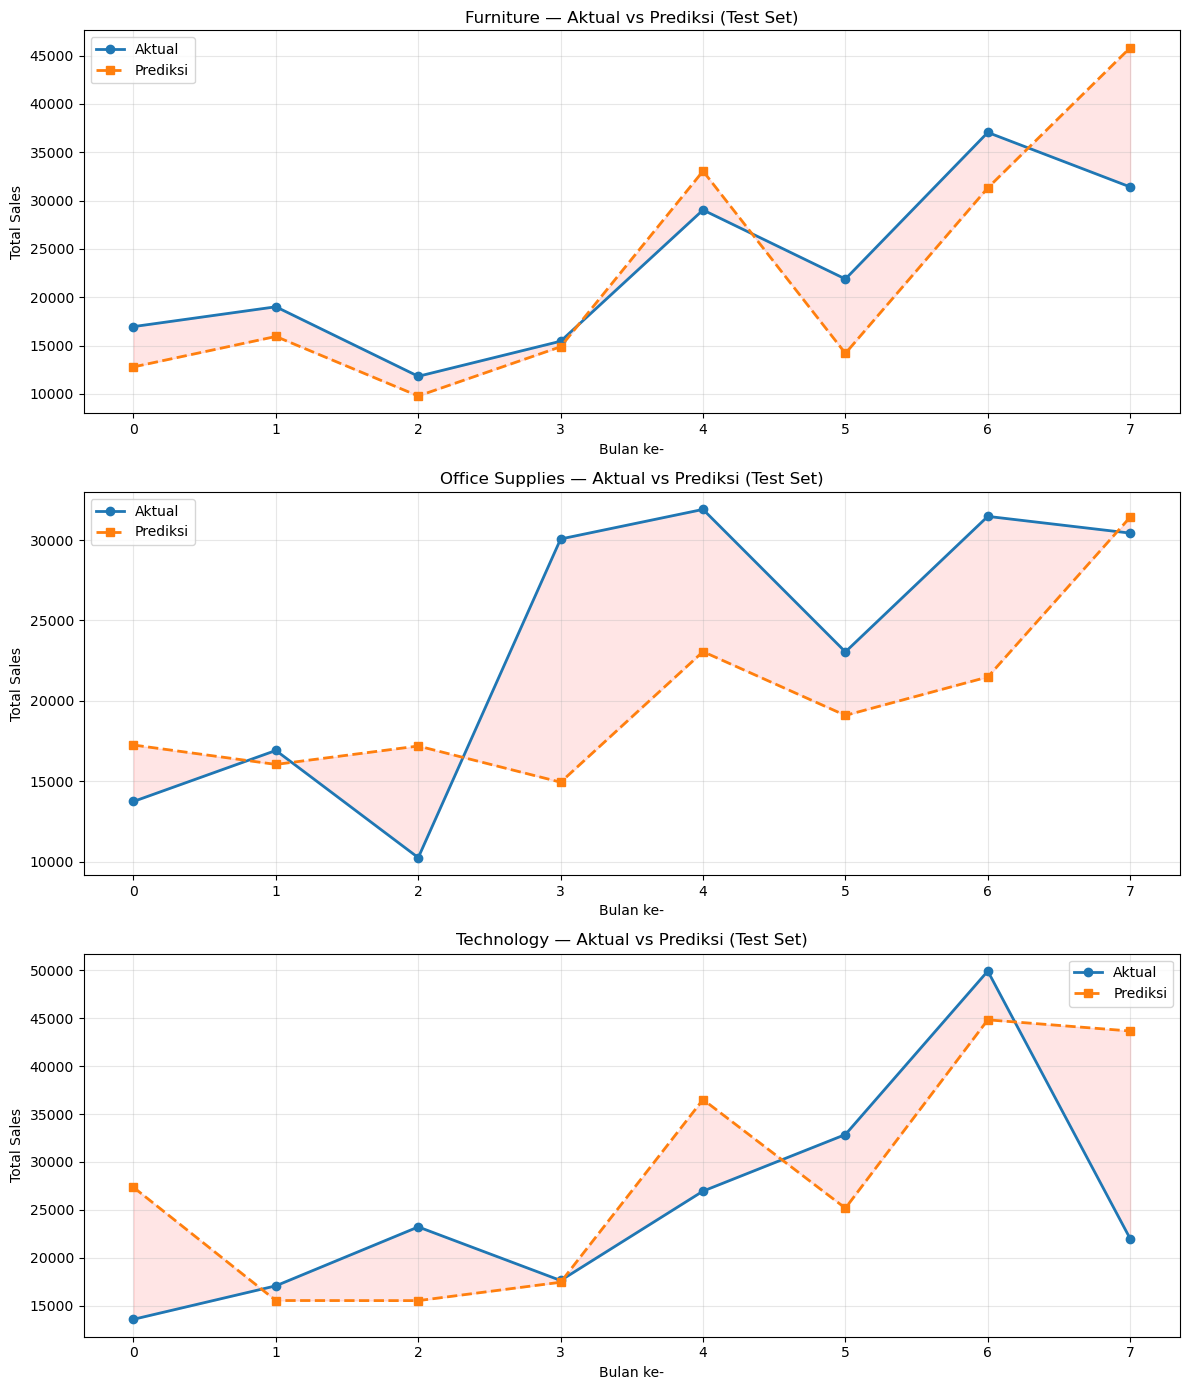

In [67]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

for ax, (cat, info) in zip(axes, tuned_models.items()):
    train = categories[cat][0]
    val   = categories[cat][1]
    test  = categories[cat][2]
    
    # Prediksi test set
    train_val = np.concatenate([train, val])
    
    if info['type'] == 'arima':
        params = info['params']
        m = ARIMA(train_val,
                  order=(params['p'], params['d'], params['q']),
                  seasonal_order=(params['seasonal_P'], params['seasonal_D'], params['seasonal_Q'], 12)).fit()
        pred_test = m.forecast(steps=len(test))
    elif info['type'] == 'theta':
        params = info['params']
        m = ThetaModel(train_val, period=params['period'],
                       deseasonalize=params['deseasonalize']).fit()
        pred_test = m.forecast(steps=len(test))
    elif info['type'] == 'omp':
        params = info['params']
        omp, scaler, seas_comp, trend_coefs, detrend_tv, deseas_tv = train_omp(
            train_val, period=params['period'],
            n_lags=params['n_lags'], n_nonzero_coefs=params['n_nonzero_coefs'])
        pred_test = predict_omp(omp, scaler, train_val, seas_comp, trend_coefs,
                                detrend_tv, steps=len(test),
                                period=params['period'], n_lags=params['n_lags'])
    
    x = range(len(test))
    ax.plot(x, test, label='Aktual', marker='o', linewidth=2)
    ax.plot(x, pred_test, label='Prediksi', marker='s', linestyle='--', linewidth=2)
    ax.fill_between(x, test, pred_test, alpha=0.1, color='red')
    ax.set_title(f'{cat} — Aktual vs Prediksi (Test Set)')
    ax.set_xlabel('Bulan ke-')
    ax.set_ylabel('Total Sales')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("aktual_vs_prediksi.png", dpi=150, bbox_inches='tight')
plt.show()

#### Cell 14 — Perbandingan Antar Model (Bar Chart)

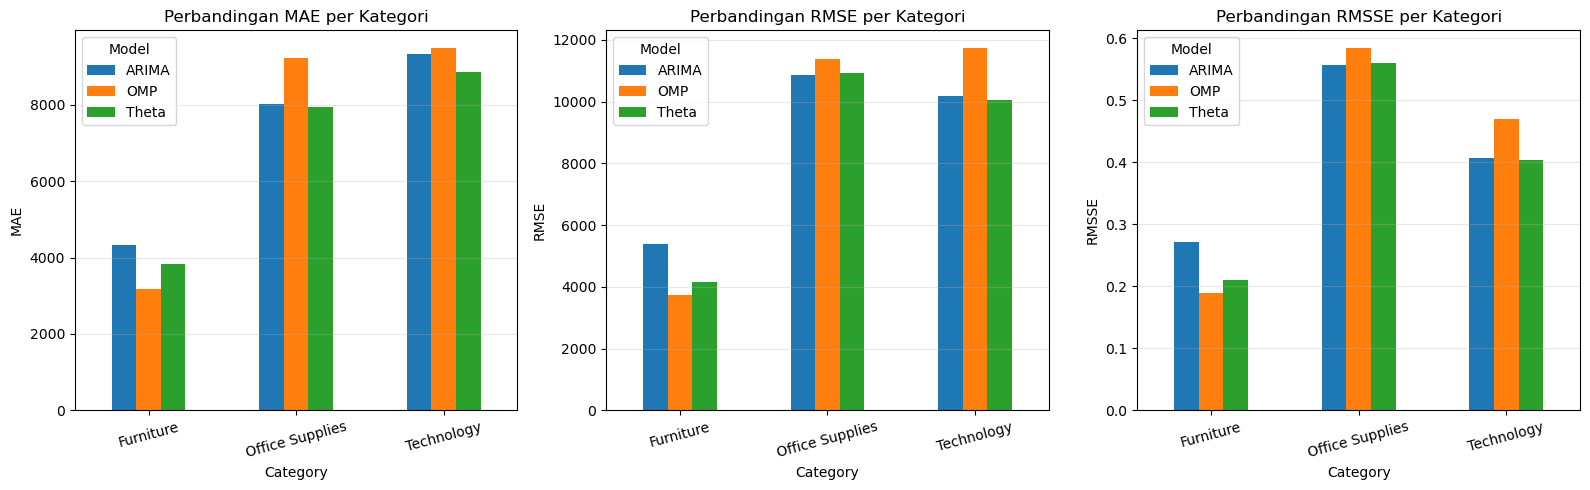

In [68]:
# Kumpulkan semua metrics dari results (sebelum tuning)
rows = []
for cat, models in results.items():
    for model_name, info in models.items():
        row = {'Category': cat, 'Model': model_name}
        row.update(info['metrics'])
        rows.append(row)

df_metrics = pd.DataFrame(rows)

# Bar chart per metric
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'RMSSE']):
    df_pivot = df_metrics.pivot(index='Category', columns='Model', values=metric)
    df_pivot.plot(kind='bar', ax=ax, rot=15)
    ax.set_title(f'Perbandingan {metric} per Kategori')
    ax.set_ylabel(metric)
    ax.legend(title='Model')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("perbandingan_model.png", dpi=150, bbox_inches='tight')
plt.show()

#### Cell 15 — Forecast 6 Bulan ke Depan

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

# Tentukan periode forecast
last_date = pd.Period("2017-12", freq="M")
forecast_periods = pd.period_range(start=last_date + 1, periods=6, freq="M")
print("Periode forecast:", forecast_periods)

forecast_results = {}

for cat, info in tuned_models.items():
    cat_slug   = cat.replace(" ", "_")
    model_type = info['type']
    params     = info['params']

    # Gunakan SELURUH data (train+val+test) untuk refit final sebelum forecast
    full_series = np.concatenate([
        categories[cat][0],  # train
        categories[cat][1],  # val
        categories[cat][2],  # test
    ])

    print(f"\nForecasting {cat} dengan {info['name']}...")

    with mlflow.start_run(run_name=f"FORECAST_{info['name']}_{cat_slug}"):

        if model_type == 'arima':
            final_model = ARIMA(
                full_series,
                order=(params['p'], params['d'], params['q']),
                seasonal_order=(params['seasonal_P'], params['seasonal_D'], params['seasonal_Q'], 12)
                    ).fit()
            forecast_values = final_model.forecast(steps=6)

            # Confidence interval
            forecast_result_obj = final_model.get_forecast(steps=6)
            forecast_ci         = forecast_result_obj.conf_int(alpha=0.05)

            if hasattr(forecast_ci, 'iloc'):        # DataFrame
                lower = forecast_ci.iloc[:, 0].values
                upper = forecast_ci.iloc[:, 1].values
            elif hasattr(forecast_ci, 'ndim'):      # numpy array
                lower = forecast_ci[:, 0]
                upper = forecast_ci[:, 1]
            else:                                   # fallback
                rmse_test = info['test_metrics']['RMSE']
                lower = forecast_values - 1.96 * rmse_test
                upper = forecast_values + 1.96 * rmse_test

        elif model_type == 'theta':
            final_model = ThetaModel(
                full_series,
                period=params['period'],
                deseasonalize=params['deseasonalize']
            ).fit()
            forecast_summary = final_model.forecast(steps=6, theta=2)

            # Theta support CI via summary_frame
            try:
                sf = final_model.summary_frame(steps=6, theta=2, alpha=0.05)
                forecast_values = sf['mean'].values
                lower           = sf['mean_ci_lower'].values
                upper           = sf['mean_ci_upper'].values
            except Exception:
                forecast_values = np.array(forecast_summary)
                lower           = forecast_values * 0.85  # fallback ±15%
                upper           = forecast_values * 1.15

        elif model_type == 'omp':
            omp, scaler, seas_comp, trend_coefs, detrend_full, deseas_full = train_omp(
                full_series,
                period=params['period'],
                n_lags=params['n_lags'],
                n_nonzero_coefs=params['n_nonzero_coefs']
            )
            forecast_values = predict_omp(
                omp, scaler, full_series, seas_comp, trend_coefs,
                detrend_full, steps=6,
                period=params['period'], n_lags=params['n_lags']
            )
            # OMP tidak punya CI bawaan — gunakan RMSE test sebagai proxy
            rmse_test = info['test_metrics']['RMSE']
            lower = np.maximum(forecast_values - 1.96 * rmse_test, 0)
            upper     = forecast_values + 1.96 * rmse_test

        forecast_results[cat] = {
            'periods': forecast_periods,
            'forecast': forecast_values,
            'lower':    lower,
            'upper':    upper,
        }

        # Log ke MLflow
        mlflow.log_param("model",    info['name'])
        mlflow.log_param("category", cat)
        mlflow.log_param("horizon",  6)
        for i, (p, f) in enumerate(zip(forecast_periods, forecast_values)):
            mlflow.log_metric(f"forecast_{p}", round(float(f), 2))

        print(f"  {'Periode':<12} {'Forecast':>12} {'Lower 95%':>12} {'Upper 95%':>12}")
        print(f"  {'-'*50}")
        for p, f, lo, hi in zip(forecast_periods, forecast_values, lower, upper):
            print(f"  {str(p):<12} {f:>12,.0f} {lo:>12,.0f} {hi:>12,.0f}")


Periode forecast: PeriodIndex(['2018-01', '2018-02', '2018-03', '2018-04', '2018-05', '2018-06'], dtype='period[M]')

Forecasting Furniture dengan OMP...
  Periode          Forecast    Lower 95%    Upper 95%
  --------------------------------------------------
  2018-01             9,742            0       22,656
  2018-02             5,095            0       18,010
  2018-03            14,590        1,675       27,505
  2018-04            13,255          340       26,170
  2018-05            16,228        3,313       29,143
  2018-06            16,926        4,011       29,841

Forecasting Office Supplies dengan ARIMA...
  Periode          Forecast    Lower 95%    Upper 95%
  --------------------------------------------------
  2018-01            25,546       12,237       38,855
  2018-02            18,224        4,600       31,848
  2018-03            21,996        8,065       35,927
  2018-04            22,274        8,042       36,506
  2018-05            21,565        7,038       

#### Cell 16 - Visualisasi

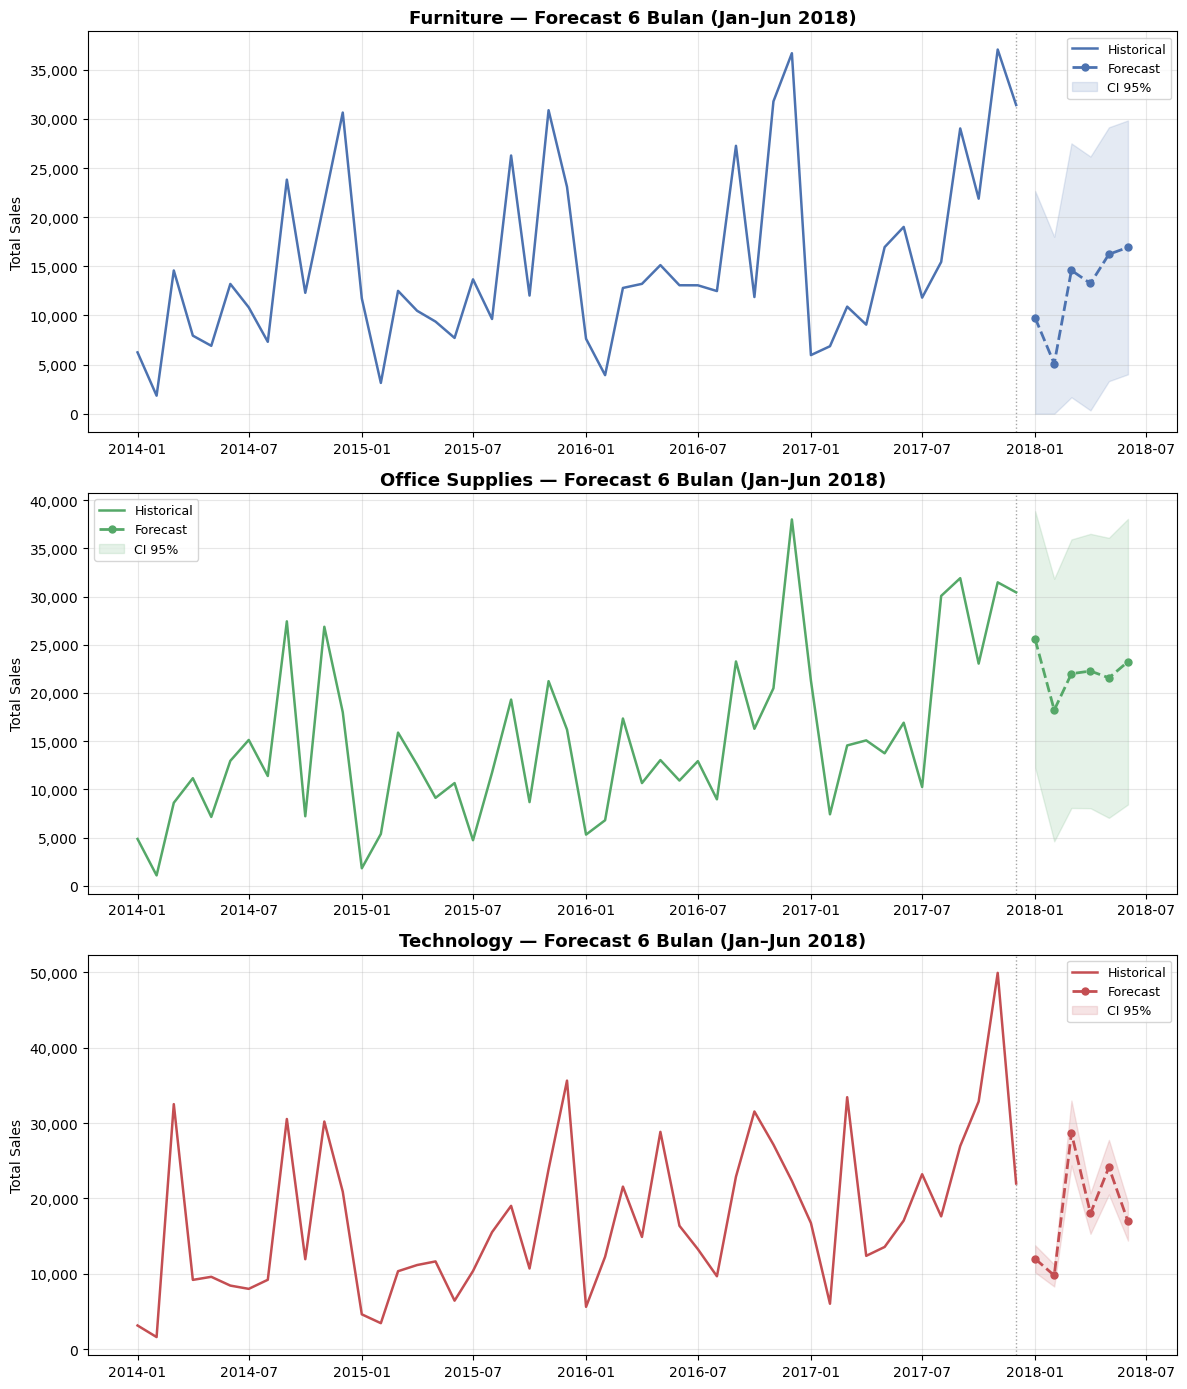


Plot tersimpan: forecast_6bulan.png


In [70]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
colors = {'Furniture': '#4C72B0', 'Office Supplies': '#55A868', 'Technology': '#C44E52'}

for ax, (cat, res) in zip(axes, forecast_results.items()):
    full_series = np.concatenate([
        categories[cat][0],
        categories[cat][1],
        categories[cat][2],
    ])

    # Buat index waktu untuk historical
    # Sesuaikan start_period dengan data Anda
    hist_index = pd.period_range(start="2014-01", periods=len(full_series), freq="M")
    fc_index   = res['periods']

    color = colors[cat]

    # Plot historical
    ax.plot(hist_index.to_timestamp(), full_series,
            color=color, linewidth=1.8, label='Historical', zorder=3)

    # Plot forecast
    ax.plot(fc_index.to_timestamp(), res['forecast'],
            color=color, linewidth=2, linestyle='--', marker='o',
            markersize=5, label='Forecast', zorder=4)

    # Confidence interval
    ax.fill_between(fc_index.to_timestamp(),
                    res['lower'], res['upper'],
                    color=color, alpha=0.15, label='CI 95%')

    # Garis pemisah historical vs forecast
    ax.axvline(pd.Period("2017-12", freq="M").to_timestamp(),
               color='gray', linestyle=':', linewidth=1, alpha=0.7)

    ax.set_title(f"{cat} — Forecast 6 Bulan (Jan–Jun 2018)", fontsize=13, fontweight='bold')
    ax.set_ylabel("Total Sales")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("forecast_6bulan.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot tersimpan: forecast_6bulan.png")

#### Cell 17 — Simpan Model Forecast

In [71]:
os.makedirs("models/forecast", exist_ok=True)

for cat, res in forecast_results.items():
    cat_slug = cat.replace(" ", "_").lower()
    model_name = tuned_models[cat]['name'].lower()
    filename = f"models/forecast/forecast_{model_name}_{cat_slug}.pkl"
    
    forecast_df = pd.DataFrame({
        'period':   [str(p) for p in res['periods']],
        'forecast': res['forecast'],
        'lower':    res['lower'],
        'upper':    res['upper'],
    })
    
    with open(filename, "wb") as f:
        pickle.dump(forecast_df, f)
    
    print(f"Saved: {filename}")

print("\nIsi folder models/forecast:")
print(os.listdir("models/forecast"))

Saved: models/forecast/forecast_omp_furniture.pkl
Saved: models/forecast/forecast_arima_office_supplies.pkl
Saved: models/forecast/forecast_theta_technology.pkl

Isi folder models/forecast:
['forecast_arima_office_supplies.pkl', 'forecast_omp_furniture.pkl', 'forecast_theta_technology.pkl']
